In [145]:
import pandas as pd
import numpy as np
import seaborn as snb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows', None)
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import plotly.graph_objects as go
import plotly.offline as py
import plotly.figure_factory as ff
import warnings
warnings.filterwarnings('ignore')

In [82]:
data= pd.read_csv("C:/Users/akrit/Downloads/data.csv")

In [83]:
data.head(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN


In [84]:
frame= pd.DataFrame({"null value":data.isnull().sum(),"percentage of  null value":(data.isnull().sum())/(data.shape[0])*100})
frame

,null value,percentage of null value
id,0,0.0
diagnosis,0,0.0
radius_mean,0,0.0
texture_mean,0,0.0
perimeter_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
concavity_mean,0,0.0
concave points_mean,0,0.0


In [141]:


trace = go.Bar(
    x=frame.index,
    y=frame['null value'],
    opacity=0.8,
    marker=dict(
        color='lightgrey',
        line=dict(color='#000000', width=1.5)
    )
)

layout = dict(title='Missing Value')

fig = dict(data=[trace], layout=layout)

py.iplot(fig)


# msno.bar(data)
# plt.show()

In [86]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [87]:

# data.drop(['Unnamed: 32'],inplace=True,axis=1)
# data.drop(['id'],inplace=True,axis=1)


In [88]:
mapp={'M':1,'B':0}
data['diagnosis']=data['diagnosis'].map(mapp)

In [89]:
data['radius_mean'].max()

28.11

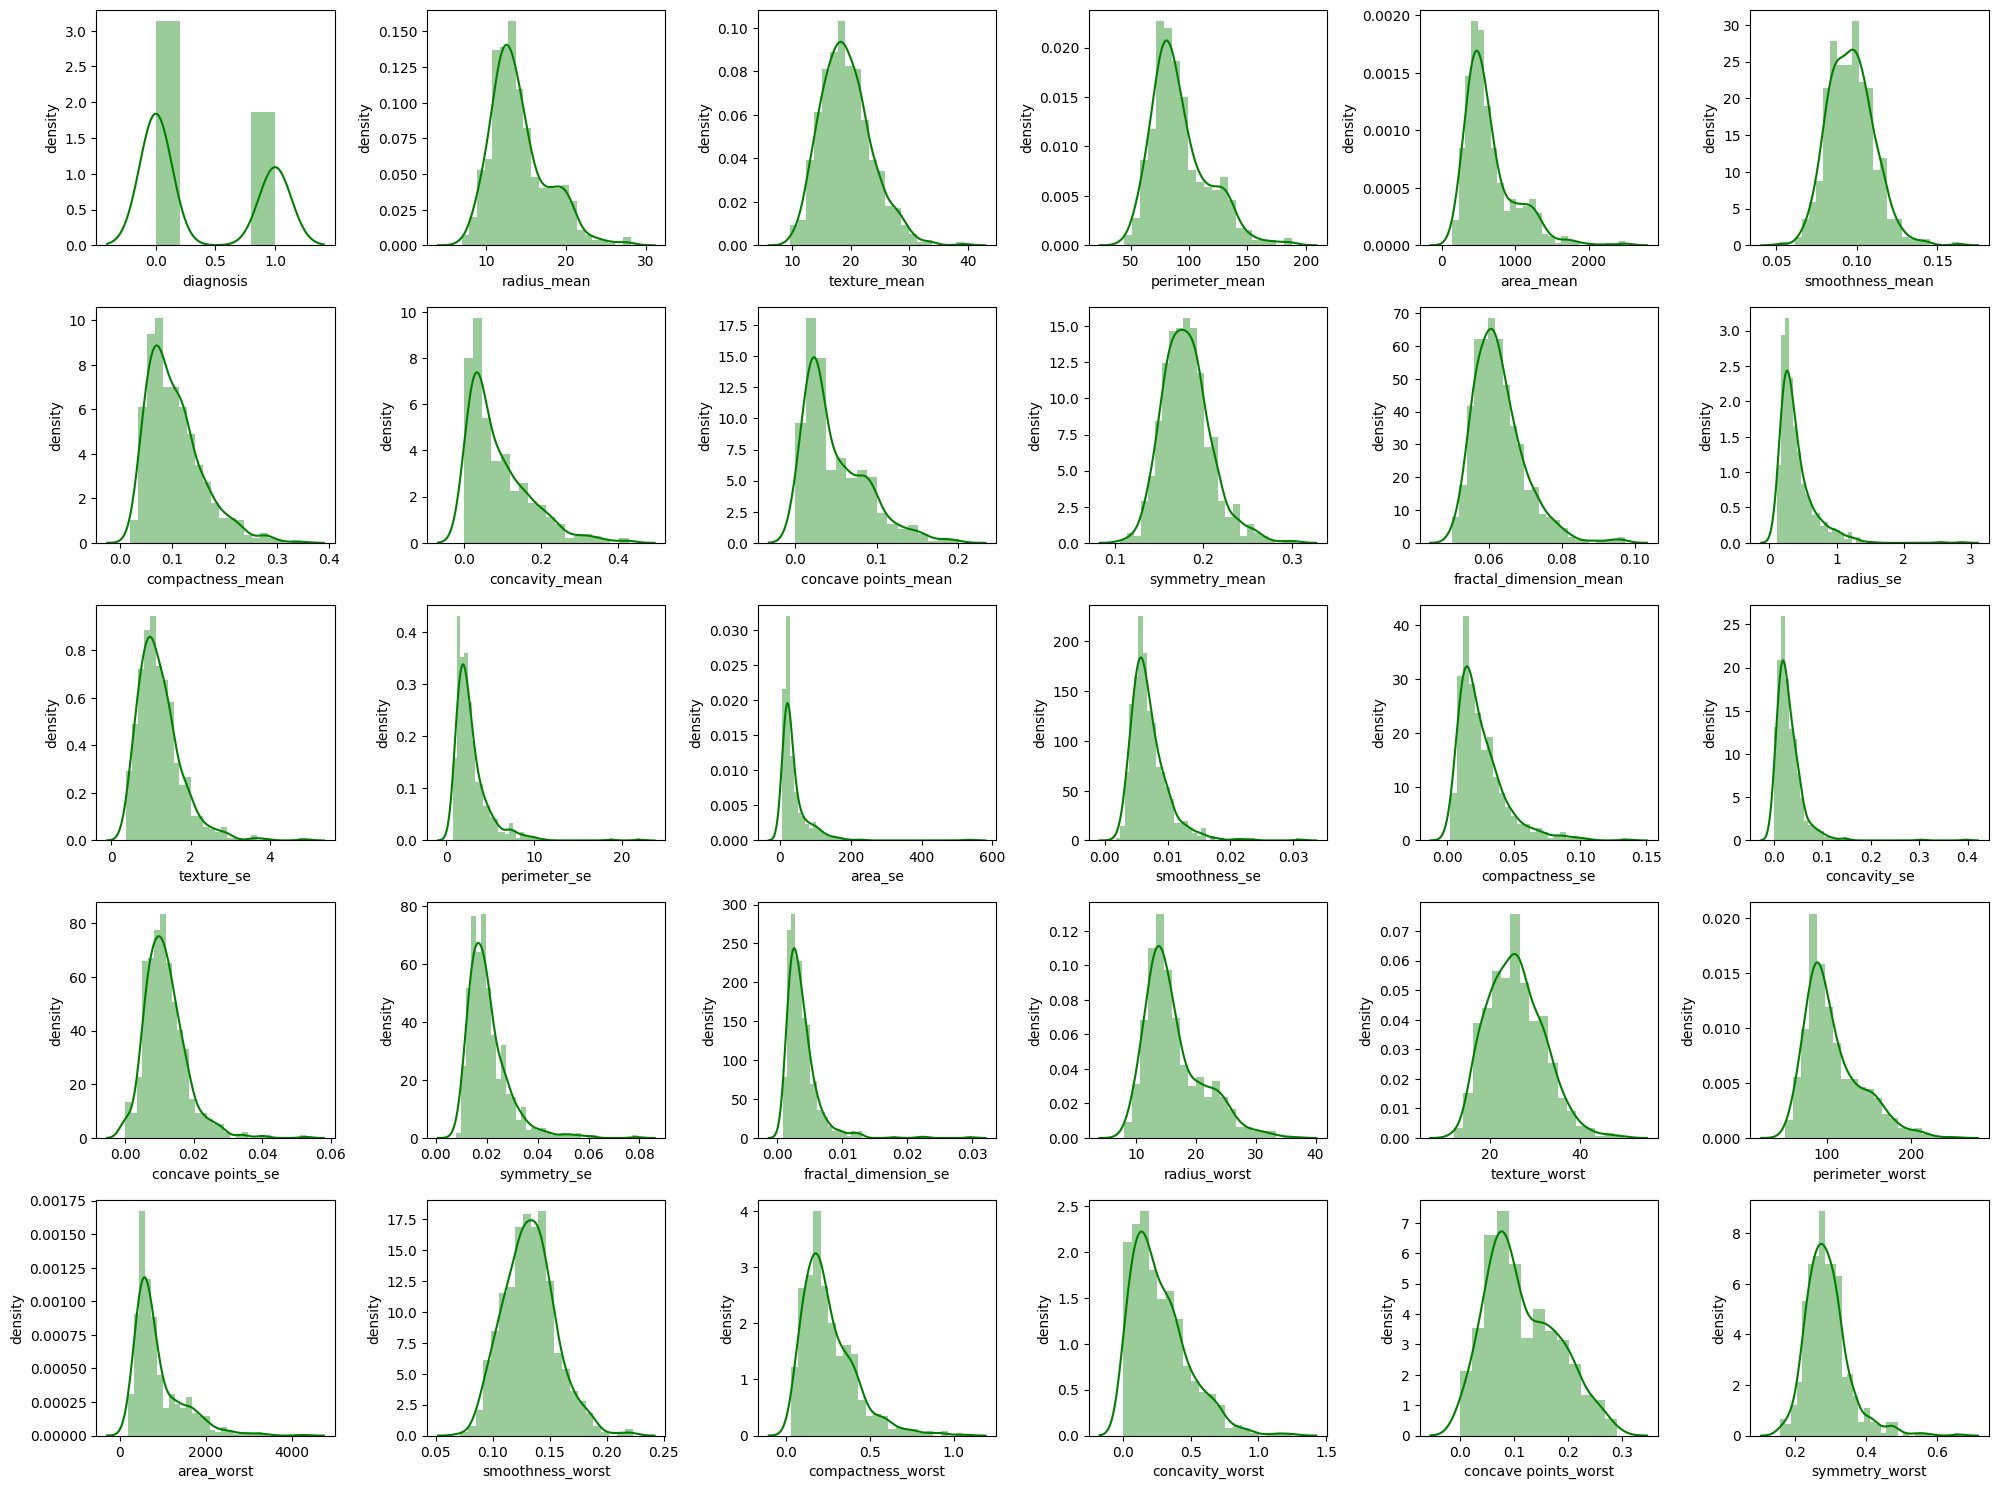

In [90]:
plt.figure(figsize=(20,15))
plotnumber=1

for columns in data:
    if plotnumber <= 30:
        ax= plt.subplot(5,6,plotnumber)
        
        
        sns.distplot(data[columns],ax=ax,color='green')
        # sns.histplot(data[columns],kde=True,ax=ax,color='green')
        
        plt.xlabel(columns)
        plt.ylabel('density')
        plotnumber +=1
    
    
plt.tight_layout()    
plt.show()

In [92]:
for col in data:
    data[col]=np.log(data[col]+1)

In [93]:
data.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.526589,1.372173,1.233102,1.761071,2.068097,0.106069,0.219122,0.233047,0.128602,0.196095,0.073033,0.553629,0.497521,1.181916,1.798329,0.006358,0.046765,0.051013,0.015623,0.029159,0.006155,1.452224,1.363164,1.828348,2.153023,0.140036,0.412232,0.430225,0.211385,0.321000,0.106471
1,0.526589,1.403963,1.369214,1.774460,2.102996,0.078201,0.072973,0.080039,0.065617,0.154034,0.053657,0.360504,0.438496,0.908722,1.671202,0.005198,0.012911,0.018261,0.013223,0.013700,0.003520,1.448732,1.433892,1.804005,2.149337,0.110392,0.157937,0.195896,0.157505,0.217485,0.081836
2,0.526589,1.393680,1.411558,1.770740,2.091049,0.098940,0.138312,0.165644,0.113648,0.172318,0.056626,0.442824,0.457730,1.000663,1.714553,0.006112,0.038527,0.036914,0.020166,0.022007,0.004550,1.435448,1.453550,1.797361,2.133486,0.126527,0.302931,0.316152,0.196822,0.268836,0.080616


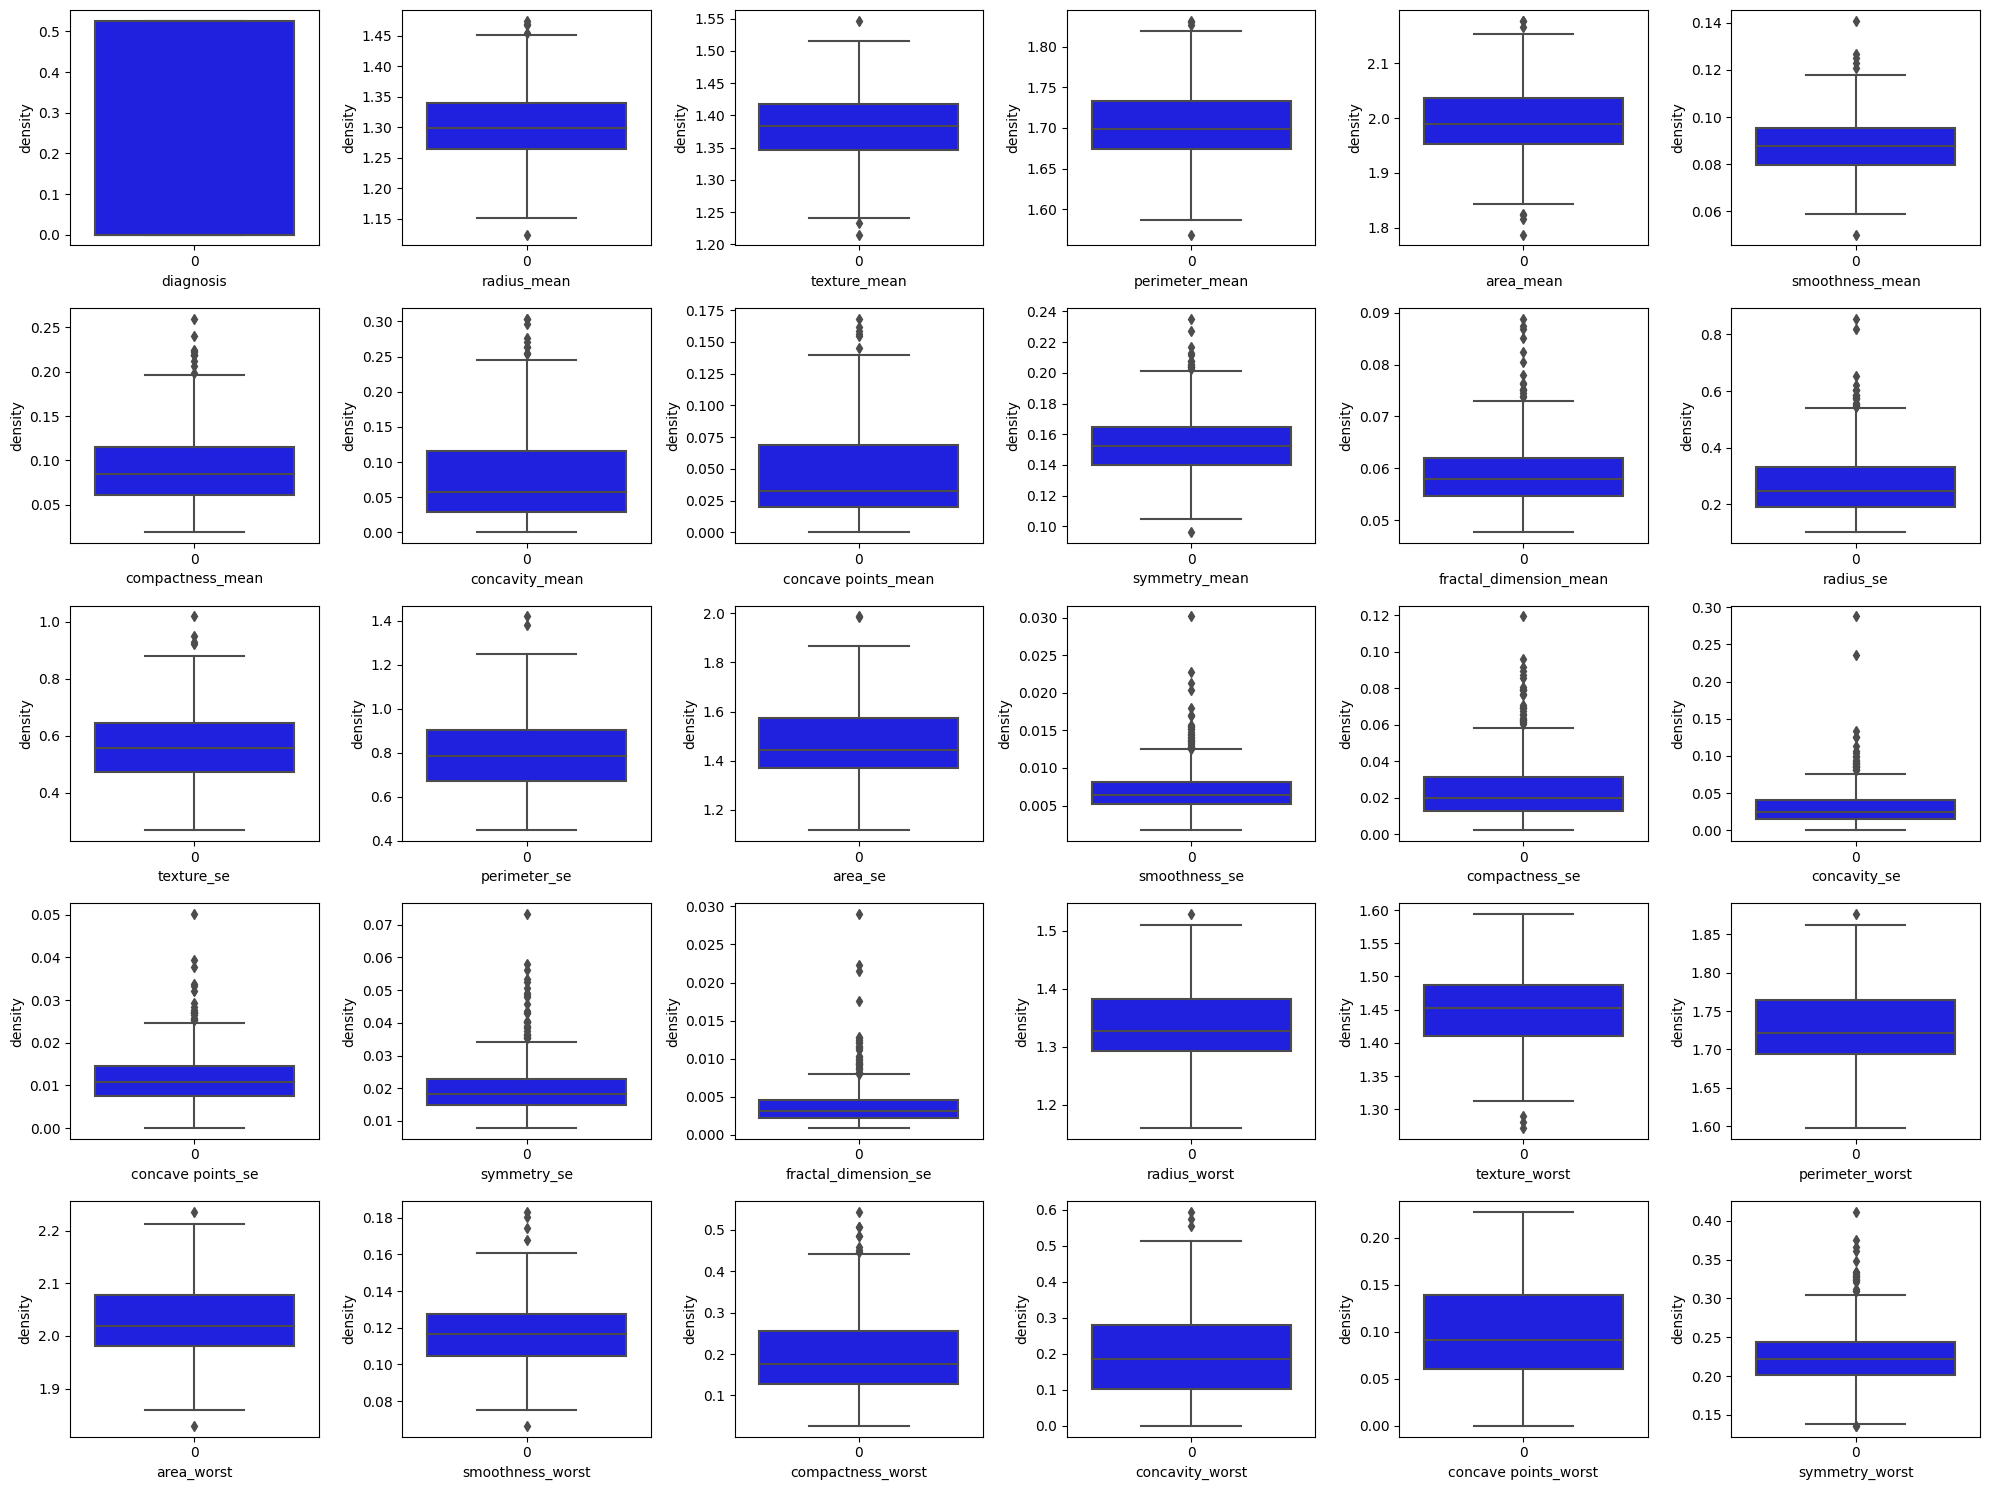

In [94]:
plt.figure(figsize=(20,15))
plotnumber=1

for columns in data:
    if plotnumber <= 30:
        ax= plt.subplot(5,6,plotnumber)
        
        
        sns.boxplot(data[columns],ax=ax,color='blue')
      
        
        plt.xlabel(columns)
        plt.ylabel('density')
        plotnumber +=1
    
    
plt.tight_layout()    
plt.show()

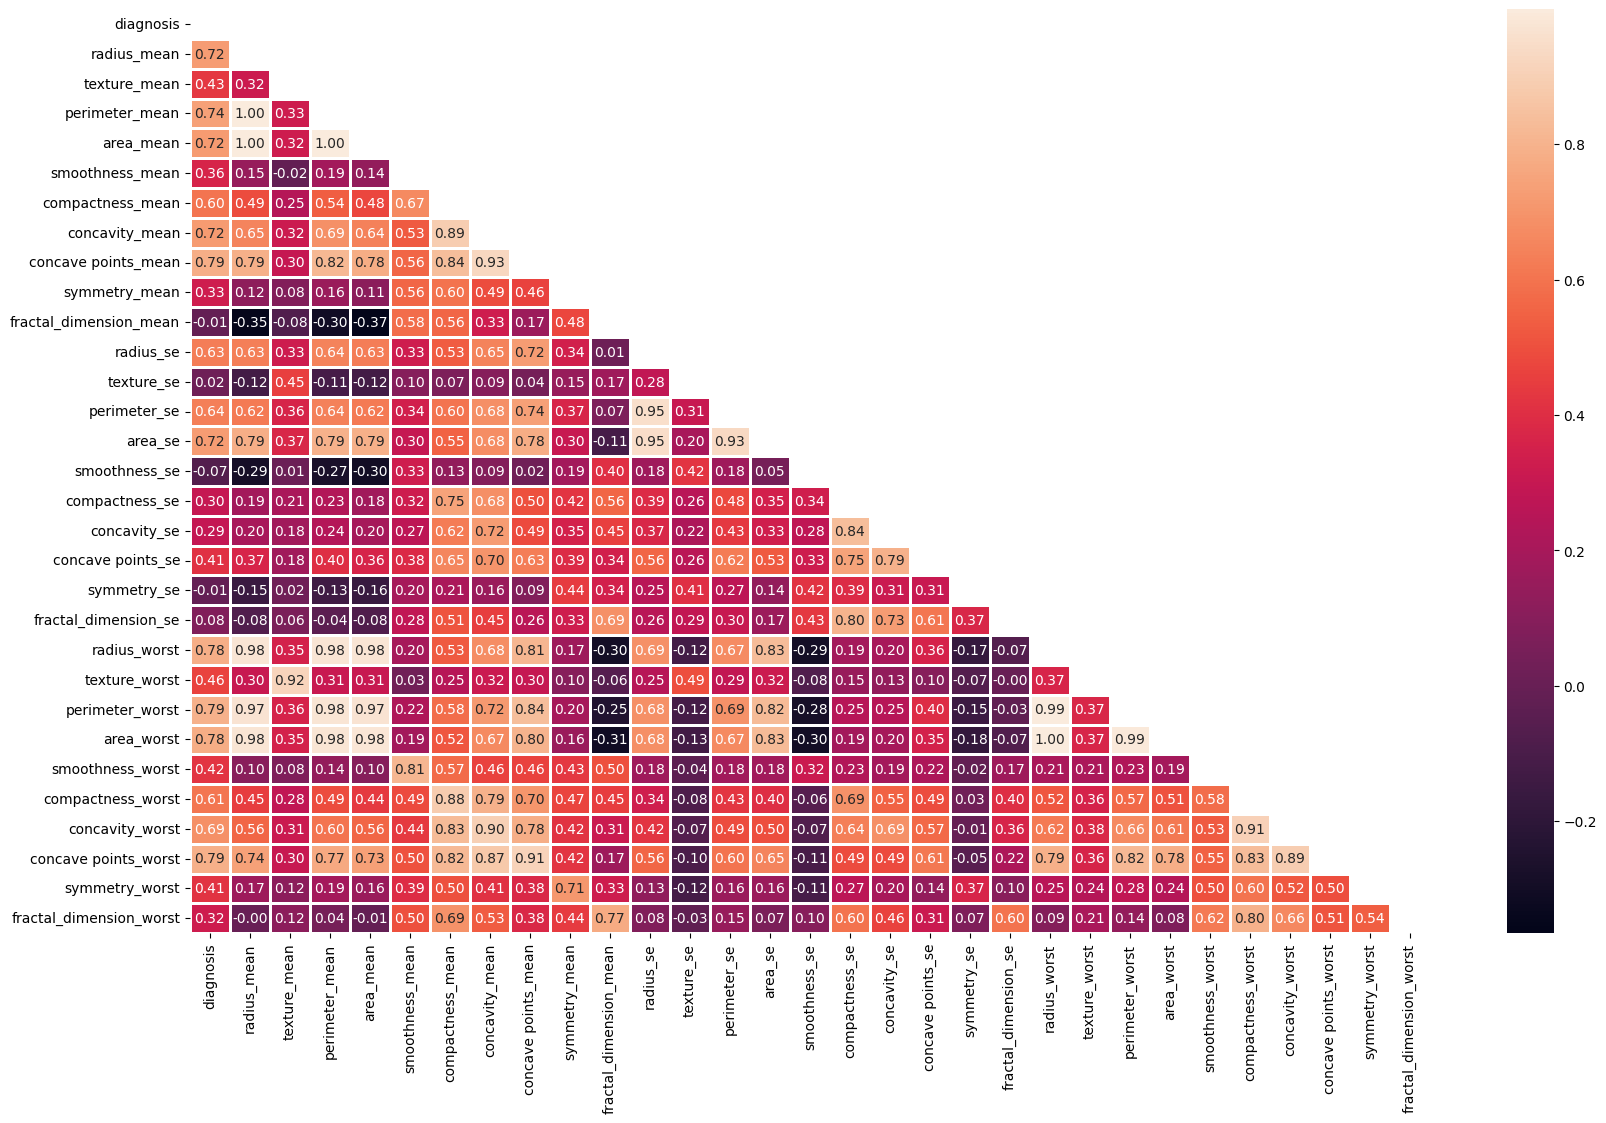

In [95]:
plt.figure(figsize = (20, 12))
corr= data.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, linewidths = 1, annot = True,fmt=".2f")
plt.show()

## target distribution

In [96]:
f= (data["diagnosis"] ==0)
B= data[f]
M=data[~f]

In [130]:

# B
# M




diagnosis
0.0    357
Name: count, dtype: int64

In [140]:


trace = go.Bar(x=[len(M), len(B)], y=['malignant', 'benign'],
               orientation='h',
               opacity=0.8,
               marker=dict(
                   color=['gold', 'blue'],
                   line=dict(color='#000000', width=1.5)
               )
              )

layout = dict(title='Count of Diagnosis')
fig = dict(data = [trace], layout=layout)
py.iplot(fig)

# -------------------------------------------------------------------------------------------------------------------------------------

malignant_percentage = (M.shape[0] / data.shape[0]) * 100
benign_percentage = (B.shape[0] / data.shape[0]) * 100


df = pd.DataFrame({"malignant": [malignant_percentage], "benign": [benign_percentage]}, index=[0])
df

trace = go.Pie(labels=['benign', 'malignant'],
               values=[df['benign'][0], df['malignant'][0]],
               textfont=dict(size=20),
               opacity=0.8,
               marker=dict(colors=['lightskyblue', 'gold'], 
                           line=dict(color='#000000', width=1.5))
              )

layout = dict(title='Distribution of diagnosis variable')
fig = dict(data=[trace], layout=layout)
py.iplot(fig)


In [188]:
def plot(column,size):
    one=M[column]
    two=B[column]
    data=[one,two]
    
    glabel=['malignant','benign']
    col=["blue","red"]
    
    fig=ff.create_distplot(data,glabel,colors=col,show_hist=True, bin_size = size, curve_type='kde')
    fig['layout'].update(title = column)

    py.iplot(fig)
    
    


In [189]:
plot('radius_mean',.5)
# plot('texture_mean', .5)
# plot('perimeter_mean', .5)
# plot('area_mean', .5)
# plot('smoothness_mean', .10)
# plot('compactness_mean', .5)
# plot('concavity_mean', .5
# plot('concave points_mean', .5)
# plot('symmetry_mean', .10)
# plot('fractal_dimension_mean', .10)
